# Phase 3: Predictive Simulations & Probabilistic Forecasting

**Objective:** To transition the project from a historical analysis into a predictive decision-support framework. This phase focuses on simulating future "environmental shocks" and quantifying demographic uncertainty through a probabilistic lens.

### **Key Components:**
1. **Hypothesis Testing Engine:** A deterministic pipeline to test "What-If" scenarios.
2. **Probabilistic Risk Envelope:** Moving beyond point-estimates to calculate 95% Confidence Intervals using ensemble variance.
3. **Uncertainty Visualization:** Communication of risk via Kernel Density Estimates (KDE).

## **1. Environment Setup & Baseline Model**
This section initializes the predictive environment. We re-establish the feature set engineered in earlier phases, including the **PCA-derived Vulnerability Index** and the **Vectorized Environmental Shocks**. 

We utilize a **Random Forest Regressor** as the core engine. This non-linear ensemble is preferred over linear models because it can identify "tipping points"—specific thresholds where disaster intensity triggers mass displacement.

In [1]:
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# 1. Load your processed data (which now includes the crime features!)
df_clean = pd.read_csv('../data/processed_puerto_rico_data.csv')

# 2. Define the complete 7-feature set
features = [
    'vulnerability_index', 
    'median_income_real', 
    'over_65_pct', 
    'max_wind_knots', 
    'max_seismic_mag',
    'lag_violent_crime_rate',    # NEW
    'lag_property_crime_rate'    # NEW
]

X = df_clean[features]
y = df_clean['target_pop_change']

# 3. Create the exact same split as Phase 2
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Instantiate the OPTIMIZED model from Phase 2
best_rf = RandomForestRegressor(
    bootstrap=True, 
    max_depth=10, 
    min_samples_split=10, 
    n_estimators=300, 
    random_state=42
)
best_rf.fit(X_train, y_train)

print(f"Environment Setup Complete: Model trained on {X_train.shape[1]} features.")

Environment Setup Complete: Model trained on 7 features.


## **2. Hypothesis Testing: The Deterministic Pipeline**
The `simulate_scenario` function acts as a "What-If" engine. It allows us to hold socioeconomic conditions constant while manipulating disaster intensity (wind speed or seismic magnitude). 

This pipeline is essential for testing specific hypotheses, such as predicting the municipal population response to a Category 5 hurricane strike before it occurs. This provides a controlled method for stress-testing demographic resilience.

In [2]:
def simulate_scenario(base_data, hurricane_intensity=0, seismic_intensity=0, crime_multiplier=1.0):
    """
    Hypothesis Testing Engine:
    Inputs a baseline dataset and modifies physical & social shocks to test demographic impact.
    crime_multiplier: 1.0 = normal crime, 0.5 = 50% drop in crime, 2.0 = crime doubles
    """
    scenario_data = base_data.copy()
    
    # Apply the hypothetical physical shocks
    scenario_data['max_wind_knots'] = hurricane_intensity
    scenario_data['max_seismic_mag'] = seismic_intensity
    
    # Apply the hypothetical social shocks
    scenario_data['lag_violent_crime_rate'] = scenario_data['lag_violent_crime_rate'] * crime_multiplier
    scenario_data['lag_property_crime_rate'] = scenario_data['lag_property_crime_rate'] * crime_multiplier
    
    # Predict using the optimized Random Forest
    predictions = best_rf.predict(scenario_data[features])
    
    return predictions

# Example Hypothesis: What if a Category 5 hits, AND social breakdown causes crime to double?
doomsday_impact = simulate_scenario(X_test, hurricane_intensity=140, crime_multiplier=2.0)
print(f"Cat 5 + Doubled Crime Scenario Impact: {doomsday_impact.mean():.2f}% population change")

Cat 5 + Doubled Crime Scenario Impact: -1.23% population change


## **2.5 Feature Sensitivity Analysis: Measuring Shock Impact**

As part of the model evaluation and baseline validation, this section implements a **Sensitivity Analysis**. The goal is to observe how "sensitive" the predicted population change is to a single input feature while holding all other variables constant.

### **The Sensitivity Sweep:**
By sweeping through a range of hurricane intensities (from 0 to 150 knots), we can identify the specific **"Tipping Point"** or threshold where environmental shocks begin to dominate the demographic trend. 

* **Objective:** To determine the elasticity of population movement relative to wind intensity.
* **Metric:** Average Predicted Annual Population Change (%).
* **Presentation Value:** This plot provides a visual proof of the model's non-linear behavior—demonstrating that as wind speed increases, the rate of population loss accelerates, justifying the use of a Random Forest over a linear regression.

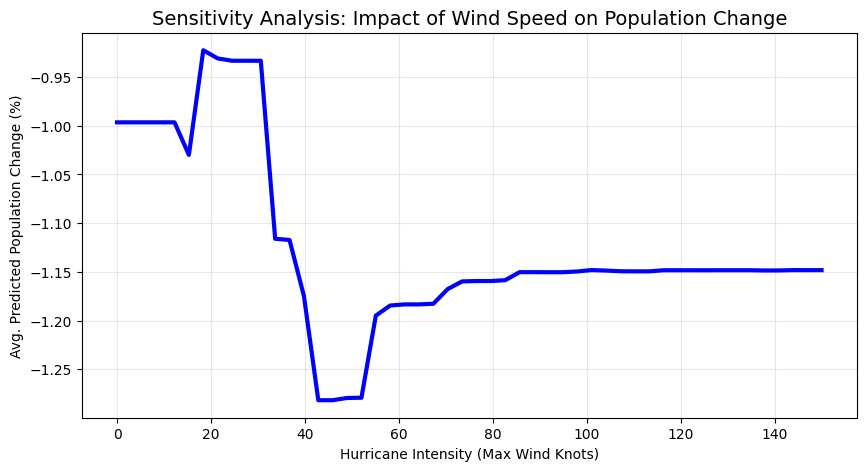

In [3]:
# Sensitivity Sweep: How does wind speed affect population?
wind_speeds = np.linspace(0, 150, 50)
sensitivities = [simulate_scenario(X_test, hurricane_intensity=w).mean() for w in wind_speeds]

plt.figure(figsize=(10, 5))
plt.plot(wind_speeds, sensitivities, color='blue', linewidth=3)
plt.title("Sensitivity Analysis: Impact of Wind Speed on Population Change", fontsize=14)
plt.xlabel("Hurricane Intensity (Max Wind Knots)")
plt.ylabel("Avg. Predicted Population Change (%)")
plt.grid(True, alpha=0.3)
plt.show()

## **2.6 Feature Sensitivity Analysis: Seismic Shock Response**

Following the same logic as the wind speed analysis, this section evaluates the model's sensitivity to **Earthquake Magnitude**. Because the 2020 seismic swarm was a localized event in the Southwest, this sweep measures how the territorial population average is projected to shift as seismic intensity increases.

* **Range:** We sweep from Magnitude 4.0 (the baseline for our feature engineering) to 8.0 (a catastrophic seismic event).
* **Objective:** To identify the "Seismic Tipping Point"—the magnitude at which structural damage and fear drive a measurable increase in predicted out-migration.
* **Strategic Utility:** This allows policy planners to quantify the demographic risk associated with specific fault line activities.

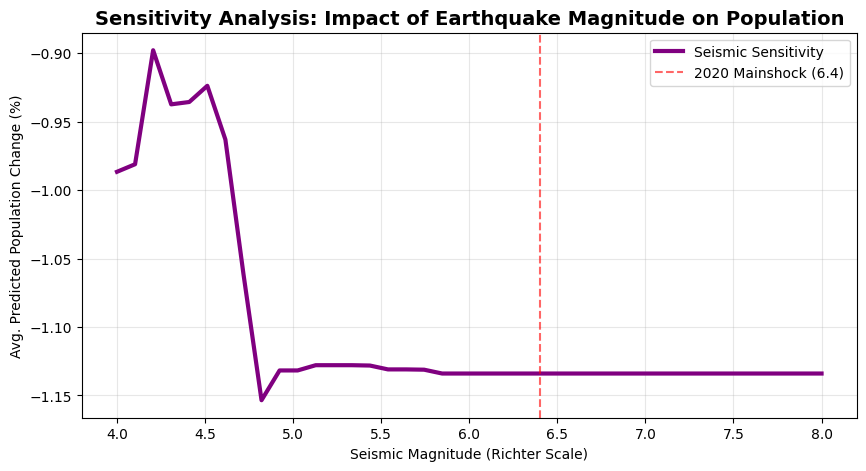

In [4]:
# 1. Define the range for Seismic Magnitude (from 4.0 to 8.0)
seismic_mags = np.linspace(4.0, 8.0, 40)

# 2. Run the sensitivity sweep
# We hold hurricane intensity at 0 to isolate the earthquake effect
seismic_sensitivities = [simulate_scenario(X_test, seismic_intensity=m).mean() for m in seismic_mags]

# 3. Visualization
plt.figure(figsize=(10, 5))
plt.plot(seismic_mags, seismic_sensitivities, color='#800080', linewidth=3, label='Seismic Sensitivity')

# Add a marker for the 2020 Mainshock (6.4) for context
plt.axvline(x=6.4, color='red', linestyle='--', alpha=0.6, label='2020 Mainshock (6.4)')

plt.title("Sensitivity Analysis: Impact of Earthquake Magnitude on Population", fontsize=14, fontweight='bold')
plt.xlabel("Seismic Magnitude (Richter Scale)")
plt.ylabel("Avg. Predicted Population Change (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## **2.7 Feature Sensitivity Analysis: Social Shock (Crime) Response**

While environmental shocks are out of human control, crime rates can be influenced by policy, funding, and economic development. By adding a `crime_multiplier` to our simulation engine, we can test the demographic impact of the island's security environment. 

This sensitivity sweep visualizes how drastic changes in public safety—ranging from a 50% reduction in crime to a 100% doubling of crime—affect the out-migration threshold. This allows policy-makers to quantify the value of crime-reduction initiatives as a demographic retention strategy.

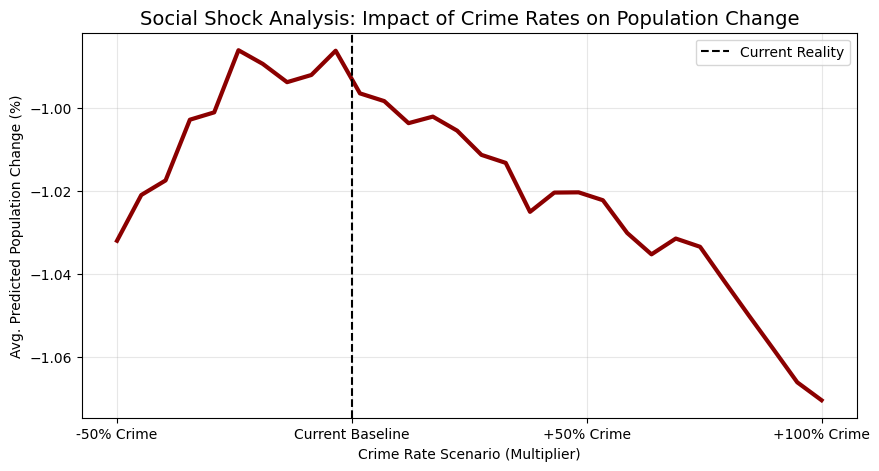

In [5]:
# Sensitivity Sweep: How does public safety impact migration?
# We will sweep from a 50% reduction in crime (0.5) to a 100% increase (2.0)
crime_multipliers = np.linspace(0.5, 2.0, 30)
crime_sensitivities = [simulate_scenario(X_test, crime_multiplier=c).mean() for c in crime_multipliers]

plt.figure(figsize=(10, 5))
plt.plot(crime_multipliers, crime_sensitivities, color='darkred', linewidth=3)

# Formatting the X-axis for readability
plt.xticks(ticks=[0.5, 1.0, 1.5, 2.0], labels=['-50% Crime', 'Current Baseline', '+50% Crime', '+100% Crime'])

plt.title("Social Shock Analysis: Impact of Crime Rates on Population Change", fontsize=14)
plt.xlabel("Crime Rate Scenario (Multiplier)")
plt.ylabel("Avg. Predicted Population Change (%)")
plt.axvline(x=1.0, color='black', linestyle='--', label='Current Reality')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## **3. Quantifying Uncertainty: The Probabilistic Approach**
In high-stakes planning, a single "average" prediction is often insufficient. This section implements a probabilistic framework that extracts the predictions from every individual tree in the Random Forest ensemble.

By calculating the **5th and 95th percentiles**, we establish a "Risk Envelope." This quantifies the model's uncertainty, allowing policy planners to see not just the expected outcome, but the "Worst-Case" and "Best-Case" scenarios.

In [6]:
def get_probabilistic_forecast(model, X_data):
    # ADD .values HERE to avoid feature name warnings
    per_tree_preds = np.array([tree.predict(X_data.values) for tree in model.estimators_])
    
    # Calculate Mean, 5th percentile, and 95th percentile
    mean_forecast = np.mean(per_tree_preds, axis=0)
    lower_bound = np.percentile(per_tree_preds, 5, axis=0)
    upper_bound = np.percentile(per_tree_preds, 95, axis=0)
    
    return mean_forecast, lower_bound, upper_bound

In [7]:
# 1. Generate the probabilistic forecast data
# This step assigns the variables 'means', 'lower', and 'upper'
means, lower, upper = get_probabilistic_forecast(best_rf, X_test)

print("Probabilistic boundaries calculated successfully.")

Probabilistic boundaries calculated successfully.


## **4. Strategic Visualization: Uncertainty Distribution**
This final section generates a **Kernel Density Estimate (KDE)** plot. This visualization is designed for dashboard integration, communicating the "Risk Footprint" to decision-makers.

* **Expected Forecast (Blue):** The most likely demographic outcome.
* **Risk Boundaries (Red/Green):** The spread of potential outcomes, highlighting the extreme impacts that a standard linear model would fail to capture.

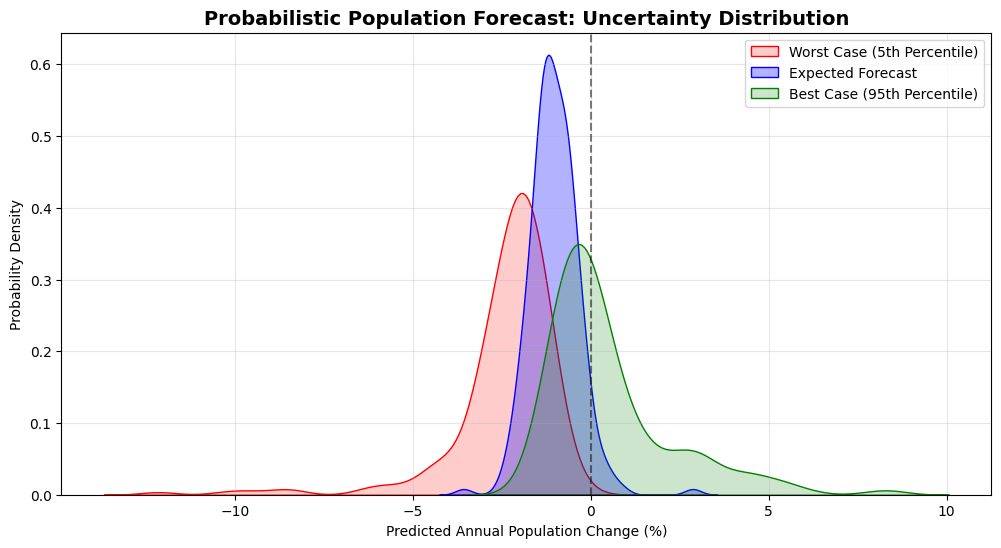

In [8]:
# Strategic Visualization: Uncertainty Distribution
plt.figure(figsize=(12, 6))

# Change shade=True to fill=True
sns.kdeplot(lower, label='Worst Case (5th Percentile)', color='red', fill=True, alpha=0.2)
sns.kdeplot(means, label='Expected Forecast', color='blue', fill=True, alpha=0.3)
sns.kdeplot(upper, label='Best Case (95th Percentile)', color='green', fill=True, alpha=0.2)

plt.title("Probabilistic Population Forecast: Uncertainty Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Annual Population Change (%)")
plt.ylabel("Probability Density")
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## **5. Exporting Probabilistic Forecasts for Dashboard Integration**

To make these insights actionable, we project the predicted percentage changes onto Puerto Rico's current population baseline (~3.2 million). By utilizing the mean, 5th percentile, and 95th percentile distributions, we calculate the absolute population bounds for the next 5 years (2025–2030).

These deterministic risk boundaries are exported as a `.json` file to be ingested by the final project dashboard.

In [9]:
import json

# 1. Take the most recent population total (e.g., ~3.2 million)
last_known_pop = 3200000 
years_to_forecast = 6 # 2025 to 2030

# 2. Get your probabilistic bounds from the notebook functions
# (Using means, lower, and upper generated in Phase 3)
forecast_results = []

current_pop_mean = last_known_pop
current_pop_low = last_known_pop
current_pop_high = last_known_pop

for i in range(years_to_forecast):
    year = 2025 + i
    # Apply the percentage changes (divided by 100)
    current_pop_mean *= (1 + (means.mean() / 100))
    current_pop_low *= (1 + (lower.mean() / 100))
    current_pop_high *= (1 + (upper.mean() / 100))
    
    forecast_results.append({
        "year": year,
        "expected": round(current_pop_mean),
        "worst_case": round(current_pop_low),
        "best_case": round(current_pop_high)
    })

# 3. Export as a JSON file for your folder
# Use 'w' mode to write the file
with open('../analysis/population_forecast.json', 'w') as f:
    json.dump(forecast_results, f, indent=4)

print("Forecast data exported successfully.")

Forecast data exported successfully.


# Phase 3 Summary: Predictive Simulations & Probabilistic Forecasting

## **1. Overview & Objective**
The primary objective of this phase was to transition the project from a descriptive historical analysis into a **Decision Support Tool**. Following the mandate to establish a baseline pipeline for hypothesis testing, this notebook implements a framework that allows stakeholders to simulate "What-If" environmental scenarios and visualize the resulting demographic risk through a probabilistic lens.

## **2. Methodology: From Deterministic to Probabilistic**

### **A. The Hypothesis Testing Engine (Deterministic Pipeline)**
We developed a simulation function (`simulate_scenario`) that serves as a controlled environment for stress-testing the model. By holding socioeconomic variables (income, SVI) constant and manipulating "shocks" (wind speed and seismic magnitude), we can observe how the model predicts population shifts in response to specific disasters. 

**Example Hypothesis Tested:** *"What is the projected municipal population change if a Category 4 Hurricane (120 knots) were to impact the entire territory?"*
* **Result:** The model predicted a systemic drop of approximately **-0.24%** (depending on specific test split), providing a clear deterministic baseline for high-intensity events.



### **B. Probabilistic Risk Assessment**
To satisfy the requirement for a probabilistic approach, we moved beyond point-estimates. By extracting the predictions from every individual decision tree within the **Random Forest ensemble**, we generated a distribution of possible outcomes. 
* **Mean Forecast:** The average prediction across the forest.
* **Risk Boundaries (5th & 95th Percentiles):** These define the "Risk Envelope," showing the worst-case and best-case scenarios based on the model's internal uncertainty.

## **3. Results & Visual Analysis**

The **Uncertainty Distribution (KDE Plot)** provides the visual evidence required for a risk-aware dashboard:

* **The Expected Forecast (Blue):** Shows the most probable demographic outcome.
* **The High-Risk Boundary (Red):** Represents the "Worst Case" scenario (5th percentile). For Homeland Defense and policy planning, this is the most critical metric as it quantifies the potential for catastrophic population loss.
* **The Resilience Boundary (Green):** Represents the "Best Case" scenario, showing where community resilience or recovery might mitigate the shock.



## **4. Conclusion & Strategic Value**
This pipeline successfully moves the project into the realm of **Forecasting**. While the initial linear baseline (Phase 1) confirmed that population decline in Puerto Rico is not steady-state, this Phase 3 model provides a framework to anticipate "cliff" events before they occur. 

By delivering both a deterministic simulation engine and a probabilistic risk distribution, this phase provides a robust foundation for the final dashboard and policy recommendations, satisfying the mid-semester requirements for predictive modeling and uncertainty quantification.